In [1]:
import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../data/lib2/UTR3_zinb_norm_2024-06-04.csv")
df

,seq,cell_type,replicate,1,2,3,4
0,CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTA...,c1,1,4132.0,6575.0,7155.0,6171.0
1,CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTA...,c1,2,3072.0,3996.0,5734.0,5854.0
2,CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTA...,c15,1,3462.0,4000.0,4899.0,6316.0
3,CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTA...,c15,2,3414.0,4373.0,5170.0,6613.0
4,CATCAGAAGCTGCTTGTGTATGTAAGGAAAATGGGGCTTCCTCCTA...,c15,3,2841.0,3321.0,5077.0,6540.0
...,...,...,...,...,...,...,...
82332,TTTCATTGCCTTGGTATAACTCCTGAGGTATGATGTGTACTATCAT...,c6,2,40.0,77.0,64.0,62.0
82333,TTTGGAGAATTTGGCTGGTTCTGTGACGCTGCTGTCACCCTCTTAT...,c6,2,234.0,31.0,76.0,25.0
82334,TTTGGTGCTAGTAGGGGAAGGGGGGAGGGAGAAGGGGGACAGGCTT...,c6,2,43.0,20.0,21.0,32.0
82335,TTTGTAACCTAGTATATTAATAAAAATTGATAATTGTGTTGTAAAA...,c6,2,6.0,2.0,35.0,52.0


In [3]:
df["seq"] = df["seq"].str.upper()

In [4]:
df = df[df["cell_type"] != "c15"]

In [5]:
df = df.groupby(by=["seq", "cell_type"])[["1", "2", "3", "4"]].sum().reset_index()

In [6]:
ct_counts = df.groupby("seq")["cell_type"].count()
ct_max = ct_counts.max()
ct_counts_seqs = ct_counts[ct_counts == ct_max].index
df = df[df["seq"].isin(ct_counts_seqs)].reset_index(drop=True).copy()

In [7]:
bins = np.arange(1, 5)
cpm = df[["1", "2", "3", "4"]]
mass_center = (cpm * bins).sum(axis=1) / cpm.sum(axis=1)
mass_center

0        2.396253
1        2.234294
2        2.497488
3        2.363411
4        2.415970
           ...   
28370    2.217097
28371    2.803389
28372    1.606870
28373    2.105108
28374    2.229508
Length: 28375, dtype: float64

In [8]:
df.insert(6, "mass_center", mass_center)
df

,seq,cell_type,1,2,3,4,mass_center
0,AAAAAAAAAAAAAAAAAAAAAAAAACACAAATACATTCACCCACCT...,c1,7803.0,7567.0,6317.0,6285.0,2.396253
1,AAAAAAAAAAAAAAAAAAAAAAAAACACAAATACATTCACCCACCT...,c17,11655.0,10389.0,7803.0,6142.0,2.234294
2,AAAAAAAAAAAAAAAAAAAAAAAAACACAAATACATTCACCCACCT...,c2,6274.0,5816.0,6332.0,6061.0,2.497488
3,AAAAAAAAAAAAAAAAAAAAAAAAACACAAATACATTCACCCACCT...,c4,8586.0,7638.0,8481.0,5550.0,2.363411
4,AAAAAAAAAAAAAAAAAAAAAAAAACACAAATACATTCACCCACCT...,c6,2888.0,2576.0,2669.0,2274.0,2.415970
...,...,...,...,...,...,...,...
28370,TTTTTTTTTTTTTTTTTTTTTTTTCCTTCCAAACTCTCCACAAACT...,c1,1759.0,650.0,264.0,1164.0,2.217097
28371,TTTTTTTTTTTTTTTTTTTTTTTTCCTTCCAAACTCTCCACAAACT...,c17,1391.0,2933.0,4367.0,3348.0,2.803389
28372,TTTTTTTTTTTTTTTTTTTTTTTTCCTTCCAAACTCTCCACAAACT...,c2,150.0,74.0,29.0,9.0,1.606870
28373,TTTTTTTTTTTTTTTTTTTTTTTTCCTTCCAAACTCTCCACAAACT...,c4,6677.0,4461.0,3281.0,2592.0,2.105108


In [9]:
mass_center_mean = df.groupby(by=["seq"])["mass_center"].mean().loc[df["seq"]].reset_index(drop=True)
mass_center_mean

0        2.381483
1        2.381483
2        2.381483
3        2.381483
4        2.381483
           ...   
28370    2.192395
28371    2.192395
28372    2.192395
28373    2.192395
28374    2.192395
Name: mass_center, Length: 28375, dtype: float64

In [10]:
mass_center_std = df.groupby(by=["seq"])["mass_center"].std().loc[df["seq"]].reset_index(drop=True)
mass_center_std

0        0.095990
1        0.095990
2        0.095990
3        0.095990
4        0.095990
           ...   
28370    0.425958
28371    0.425958
28372    0.425958
28373    0.425958
28374    0.425958
Name: mass_center, Length: 28375, dtype: float64

In [11]:
df.insert(7, "mass_center_mean", mass_center_mean)
df.insert(8, "mass_center_std", mass_center_std)
df

,seq,cell_type,1,2,3,4,mass_center,mass_center_mean,mass_center_std
0,AAAAAAAAAAAAAAAAAAAAAAAAACACAAATACATTCACCCACCT...,c1,7803.0,7567.0,6317.0,6285.0,2.396253,2.381483,0.095990
1,AAAAAAAAAAAAAAAAAAAAAAAAACACAAATACATTCACCCACCT...,c17,11655.0,10389.0,7803.0,6142.0,2.234294,2.381483,0.095990
2,AAAAAAAAAAAAAAAAAAAAAAAAACACAAATACATTCACCCACCT...,c2,6274.0,5816.0,6332.0,6061.0,2.497488,2.381483,0.095990
3,AAAAAAAAAAAAAAAAAAAAAAAAACACAAATACATTCACCCACCT...,c4,8586.0,7638.0,8481.0,5550.0,2.363411,2.381483,0.095990
4,AAAAAAAAAAAAAAAAAAAAAAAAACACAAATACATTCACCCACCT...,c6,2888.0,2576.0,2669.0,2274.0,2.415970,2.381483,0.095990
...,...,...,...,...,...,...,...,...,...
28370,TTTTTTTTTTTTTTTTTTTTTTTTCCTTCCAAACTCTCCACAAACT...,c1,1759.0,650.0,264.0,1164.0,2.217097,2.192395,0.425958
28371,TTTTTTTTTTTTTTTTTTTTTTTTCCTTCCAAACTCTCCACAAACT...,c17,1391.0,2933.0,4367.0,3348.0,2.803389,2.192395,0.425958
28372,TTTTTTTTTTTTTTTTTTTTTTTTCCTTCCAAACTCTCCACAAACT...,c2,150.0,74.0,29.0,9.0,1.606870,2.192395,0.425958
28373,TTTTTTTTTTTTTTTTTTTTTTTTCCTTCCAAACTCTCCACAAACT...,c4,6677.0,4461.0,3281.0,2592.0,2.105108,2.192395,0.425958


In [12]:
diffs = (df["mass_center"] - df["mass_center_mean"])
zscores = diffs / df["mass_center_std"]

In [13]:
df.insert(8, "diff", diffs)
df.insert(9, "zscore", zscores)
df

,seq,cell_type,1,2,3,4,mass_center,mass_center_mean,diff,zscore,mass_center_std
0,AAAAAAAAAAAAAAAAAAAAAAAAACACAAATACATTCACCCACCT...,c1,7803.0,7567.0,6317.0,6285.0,2.396253,2.381483,0.014770,0.153872,0.095990
1,AAAAAAAAAAAAAAAAAAAAAAAAACACAAATACATTCACCCACCT...,c17,11655.0,10389.0,7803.0,6142.0,2.234294,2.381483,-0.147189,-1.533391,0.095990
2,AAAAAAAAAAAAAAAAAAAAAAAAACACAAATACATTCACCCACCT...,c2,6274.0,5816.0,6332.0,6061.0,2.497488,2.381483,0.116005,1.208515,0.095990
3,AAAAAAAAAAAAAAAAAAAAAAAAACACAAATACATTCACCCACCT...,c4,8586.0,7638.0,8481.0,5550.0,2.363411,2.381483,-0.018072,-0.188273,0.095990
4,AAAAAAAAAAAAAAAAAAAAAAAAACACAAATACATTCACCCACCT...,c6,2888.0,2576.0,2669.0,2274.0,2.415970,2.381483,0.034487,0.359276,0.095990
...,...,...,...,...,...,...,...,...,...,...,...
28370,TTTTTTTTTTTTTTTTTTTTTTTTCCTTCCAAACTCTCCACAAACT...,c1,1759.0,650.0,264.0,1164.0,2.217097,2.192395,0.024702,0.057992,0.425958
28371,TTTTTTTTTTTTTTTTTTTTTTTTCCTTCCAAACTCTCCACAAACT...,c17,1391.0,2933.0,4367.0,3348.0,2.803389,2.192395,0.610994,1.434402,0.425958
28372,TTTTTTTTTTTTTTTTTTTTTTTTCCTTCCAAACTCTCCACAAACT...,c2,150.0,74.0,29.0,9.0,1.606870,2.192395,-0.585524,-1.374607,0.425958
28373,TTTTTTTTTTTTTTTTTTTTTTTTCCTTCCAAACTCTCCACAAACT...,c4,6677.0,4461.0,3281.0,2592.0,2.105108,2.192395,-0.087286,-0.204917,0.425958


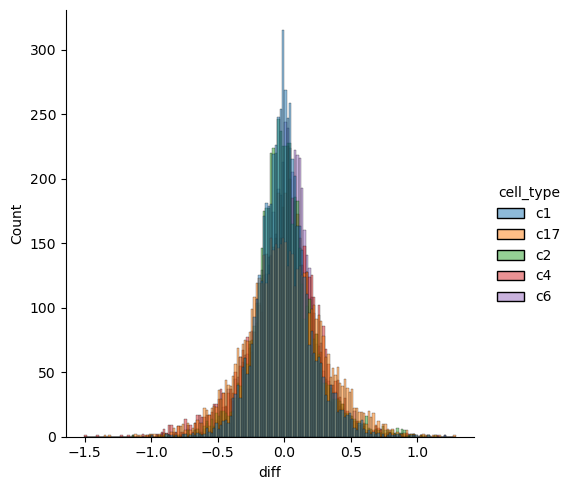

In [14]:
sns.displot(x=df["diff"], hue=df["cell_type"])

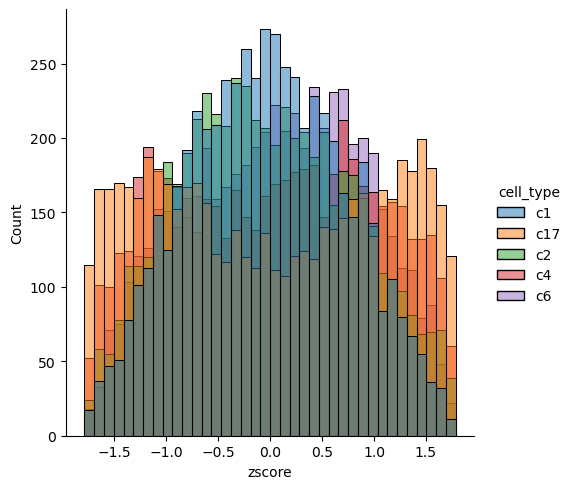

In [15]:
sns.displot(x=df["zscore"], hue=df["cell_type"])

In [16]:
df.to_csv("UTR3_zscores_2024-06-04.csv", index=False)

In [17]:
df['seq'].nunique()

5675